We begin by importing all the tools used in our ML pipeline, exactly as outlined in the report.
This includes pandas and NumPy for preprocessing, scikit-learn for the baseline model and scaling, and PyTorch for the MLP architecture described in the “Proposed Method” section.
Matplotlib and Seaborn support the exploratory steps mentioned in the Introduction and Related Work, where we justify feature selection.

Cell 1 — Imports & Setup (Code Cell)

In [23]:
import random
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, random_split

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

sns.set(style="whitegrid", context="notebook")

# Reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

Here we load the Gym Members Exercise Dataset — the same dataset referenced throughout the report.
Previewing the first few rows lets us confirm the variables described in the Introduction: demographic features, physiological features, workout intensity indicators, and our target, Calories_Burned.
This mirrors the “System Architecture” data-ingestion step in the report.

Cell 2 — Load + Clean Data (Code Cell)
## 1. Data Loading and Preprocessing

In [24]:
# Load CSV
df = pd.read_csv('gym_members_exercise_tracking.csv')
df.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39


Before preprocessing, we visualize raw patterns in the data.
This directly ties into the motivation given in the Related Work — traditional MET formulas oversimplify relationships, so we visually check for nonlinear trends.
The Weight vs Height plot and the pairplot help us identify which features show real structure, preparing us for the “feature selection” decisions reported later.

2. Quick exploratory plots (on the raw data)

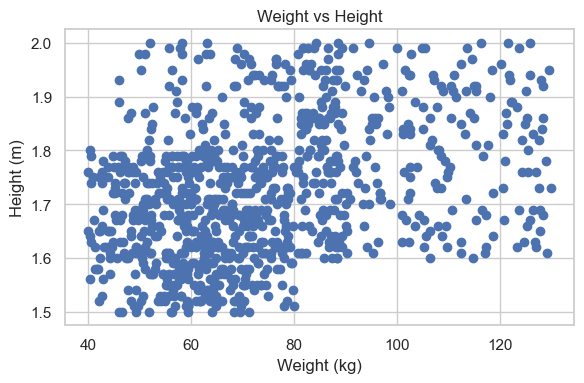

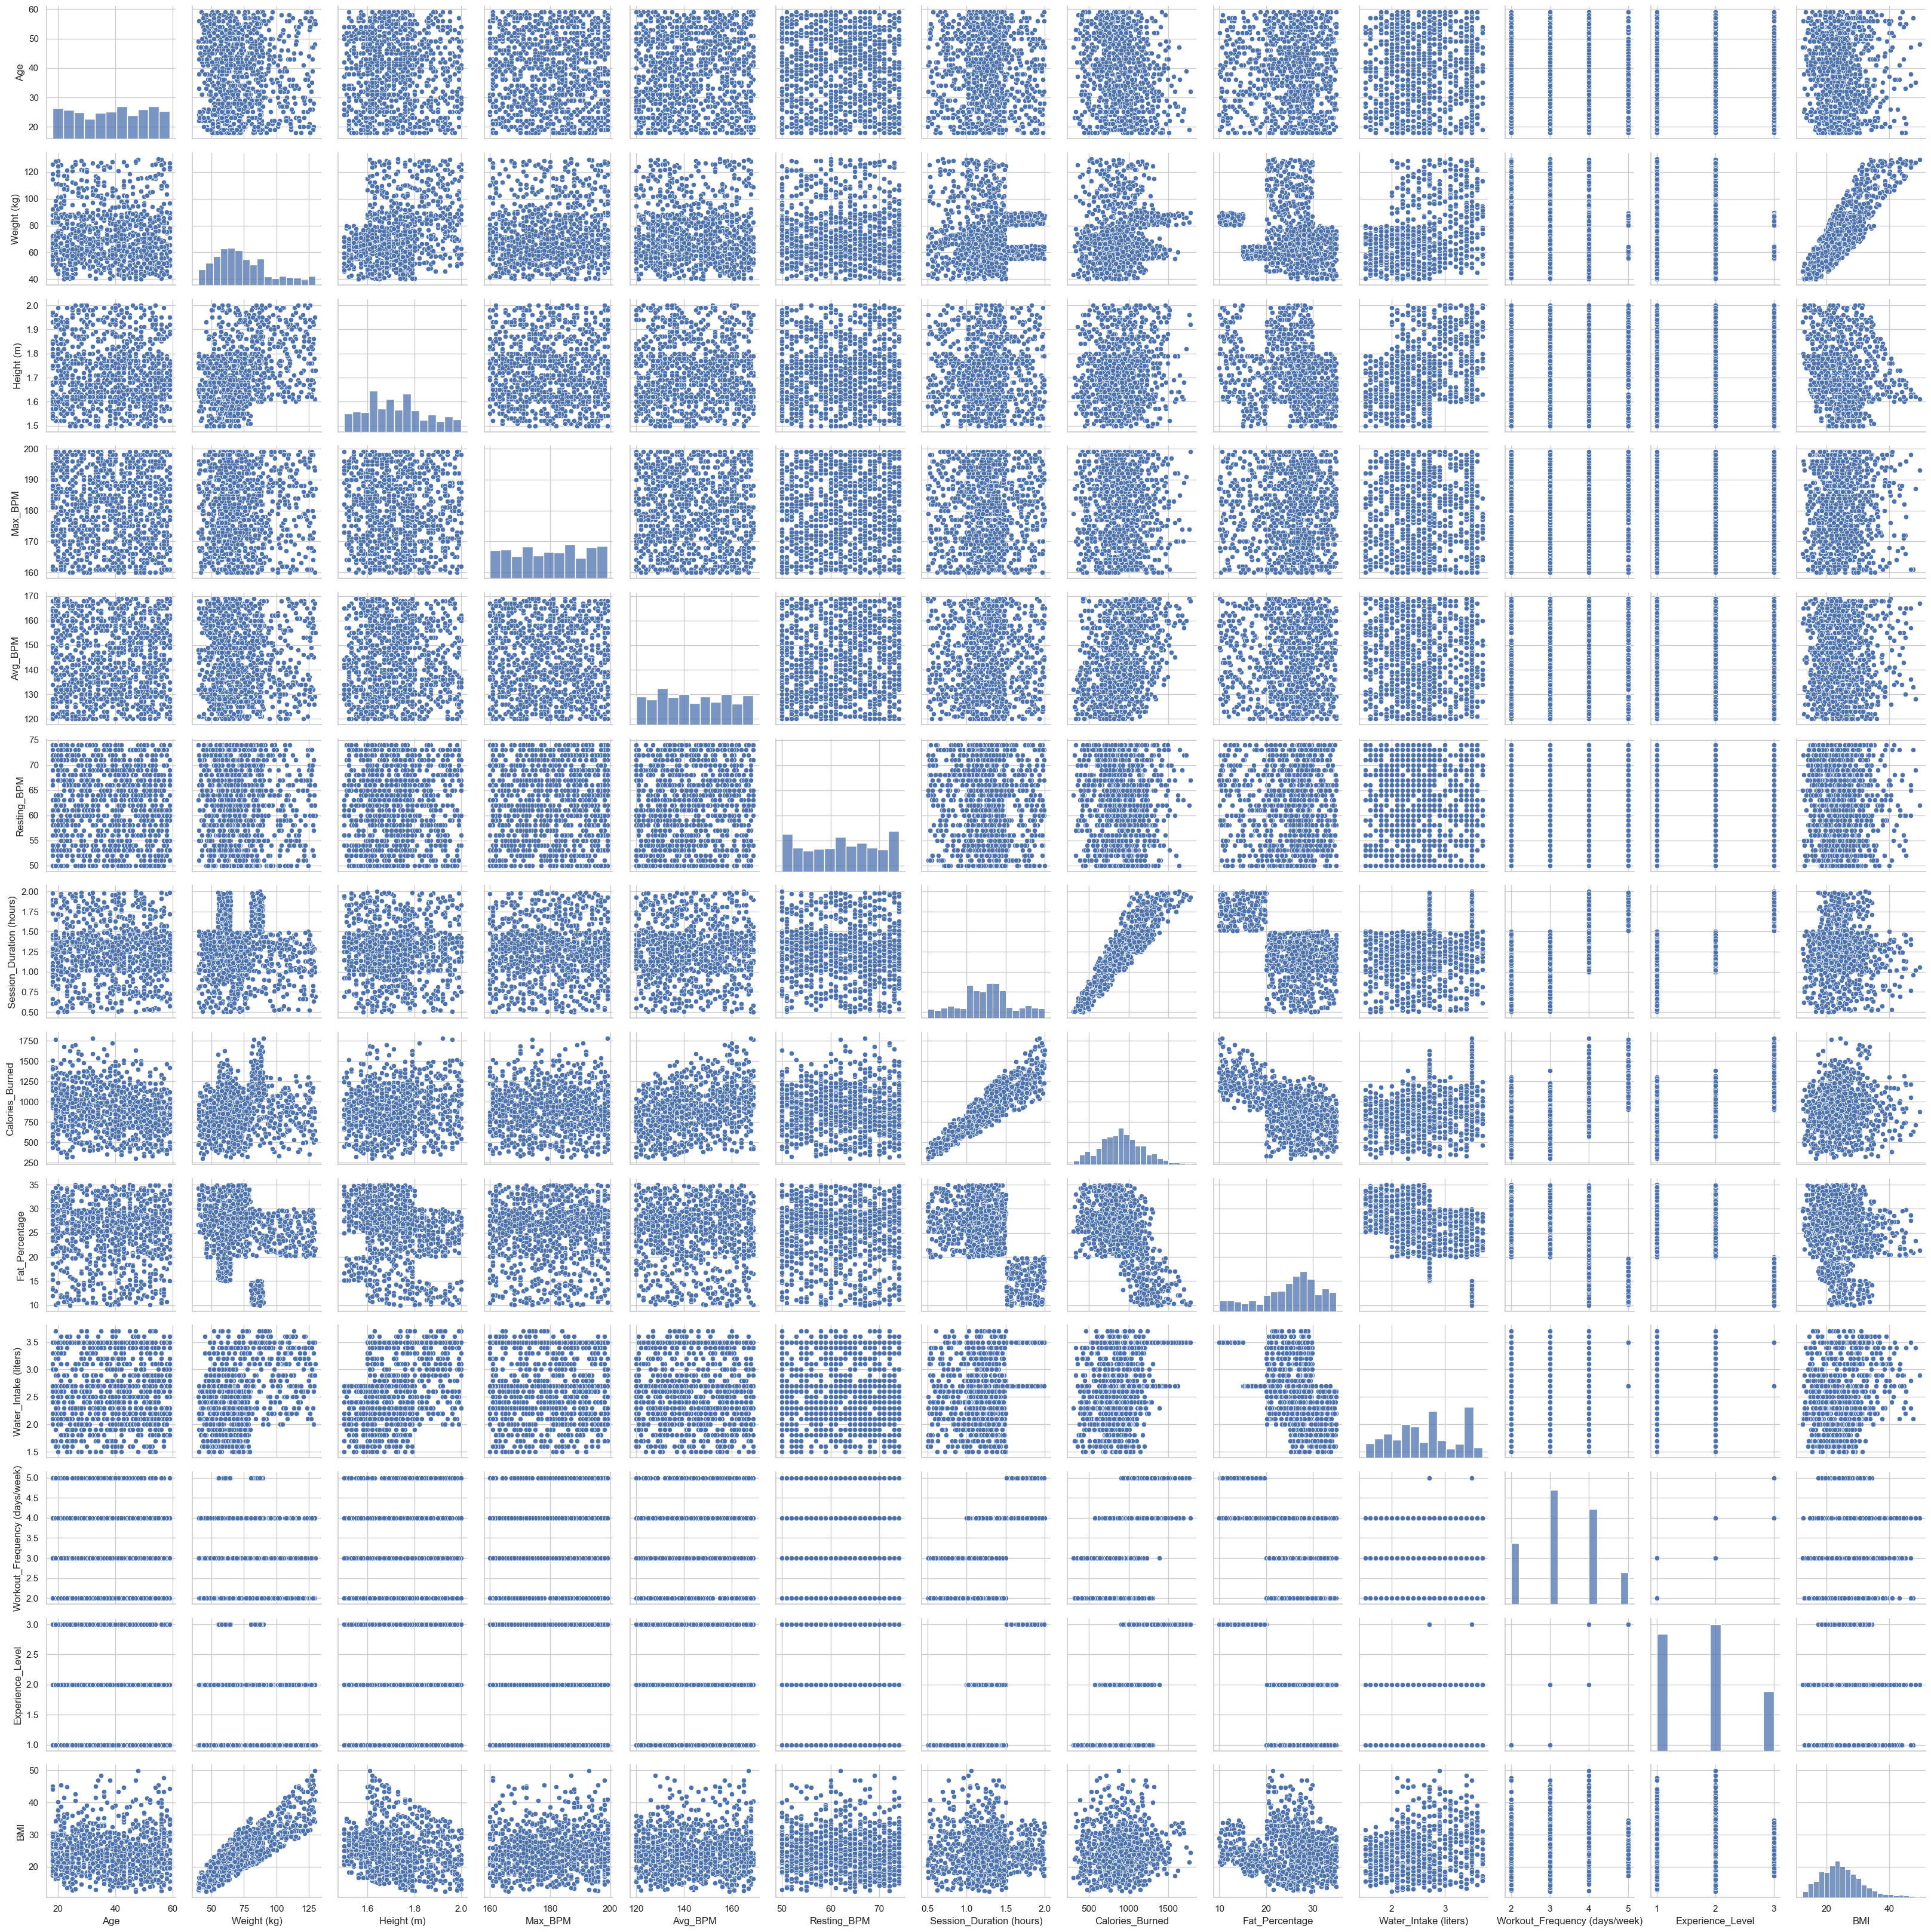

In [25]:
# 2.1 Weight vs Height joint plot
plt.figure(figsize=(6, 4))
plt.scatter(df['Weight (kg)'], df['Height (m)'])
plt.title('Weight vs Height')
plt.xlabel('Weight (kg)')
plt.ylabel('Height (m)')
plt.tight_layout()
plt.show()

# 2.2 Pairplot of numeric features for visual inspection
numeric_cols = df.select_dtypes(include=['number']).columns
df_explore = df[numeric_cols]

sns.pairplot(df_explore, height=2.5)
plt.tight_layout()
plt.show()

3.Handle missing values (on full dataframe)

In line with the “Preprocessing Module” described in the report, we handle missing numeric values with column means and categorical values with the mode.
This ensures the dataset is clean and consistent before modeling.
It also follows the reproducible pipeline described in Section III, where missing-value handling is part of our standardized workflow.

In [26]:
num_cols = df.select_dtypes(include=[np.number]).columns
cat_cols = df.select_dtypes(exclude=[np.number]).columns

# Numeric: fill with column means
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

# Categorical: fill with most frequent value (mode)
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

df.isna().sum()


Age                              0
Gender                           0
Weight (kg)                      0
Height (m)                       0
Max_BPM                          0
Avg_BPM                          0
Resting_BPM                      0
Session_Duration (hours)         0
Calories_Burned                  0
Workout_Type                     0
Fat_Percentage                   0
Water_Intake (liters)            0
Workout_Frequency (days/week)    0
Experience_Level                 0
BMI                              0
dtype: int64

Here we add Workout Intensity, which the report highlights as a meaningful ratio capturing exercise effort — something MET-based formulas ignore.
By dividing Avg_BPM by Resting_BPM, we align with the report’s argument that physiological indicators must be contextualized rather than used in isolation.
This step appears explicitly in the Feature Engineering subsection of the report.

4. Feature Engineering

In [27]:
# Feature Engineering
df['Workout_Intensity'] = df['Avg_BPM'] / df['Resting_BPM']
df[['Avg_BPM', 'Resting_BPM', 'Workout_Intensity']].head()

,Avg_BPM,Resting_BPM,Workout_Intensity
0,157,60,2.616667
1,151,66,2.287879
2,122,54,2.259259
3,164,56,2.928571
4,158,68,2.323529


Next, we drop features that the exploratory analysis showed were either weakly correlated with calorie burn or redundant.
As mentioned in the report, BMI already encodes height and weight, so removing those helps simplify the feature space.
This reduction step mirrors the rationale in Section III.B, where we justify minimizing noisy features before training.

 5. Drop features based on pairplot inspection
   - low/no relationship with target (Calories_Burned)
   - or redundant because BMI already encodes height/weight

In [28]:
drop_from_pairplot = [
    'Age',
    'Resting_BPM',
    'Water_Intake (liters)',
    'Workout_Frequency (days/week)',
    'Fat_Percentage',
    'Weight (kg)',
    'Height (m)'
]

# Only drop columns that actually exist (defensive)
drop_from_pairplot = [c for c in drop_from_pairplot if c in df.columns]

df_reduced = df.drop(columns=drop_from_pairplot)
print("After dropping low-value / redundant features:\n", df_reduced.columns, "\n")

After dropping low-value / redundant features:
 Index(['Gender', 'Max_BPM', 'Avg_BPM', 'Session_Duration (hours)',
       'Calories_Burned', 'Workout_Type', 'Experience_Level', 'BMI',
       'Workout_Intensity'],
      dtype='object') 



 6. Correlation matrix on numeric features ONLY
    (temporarily drop categorical variables)

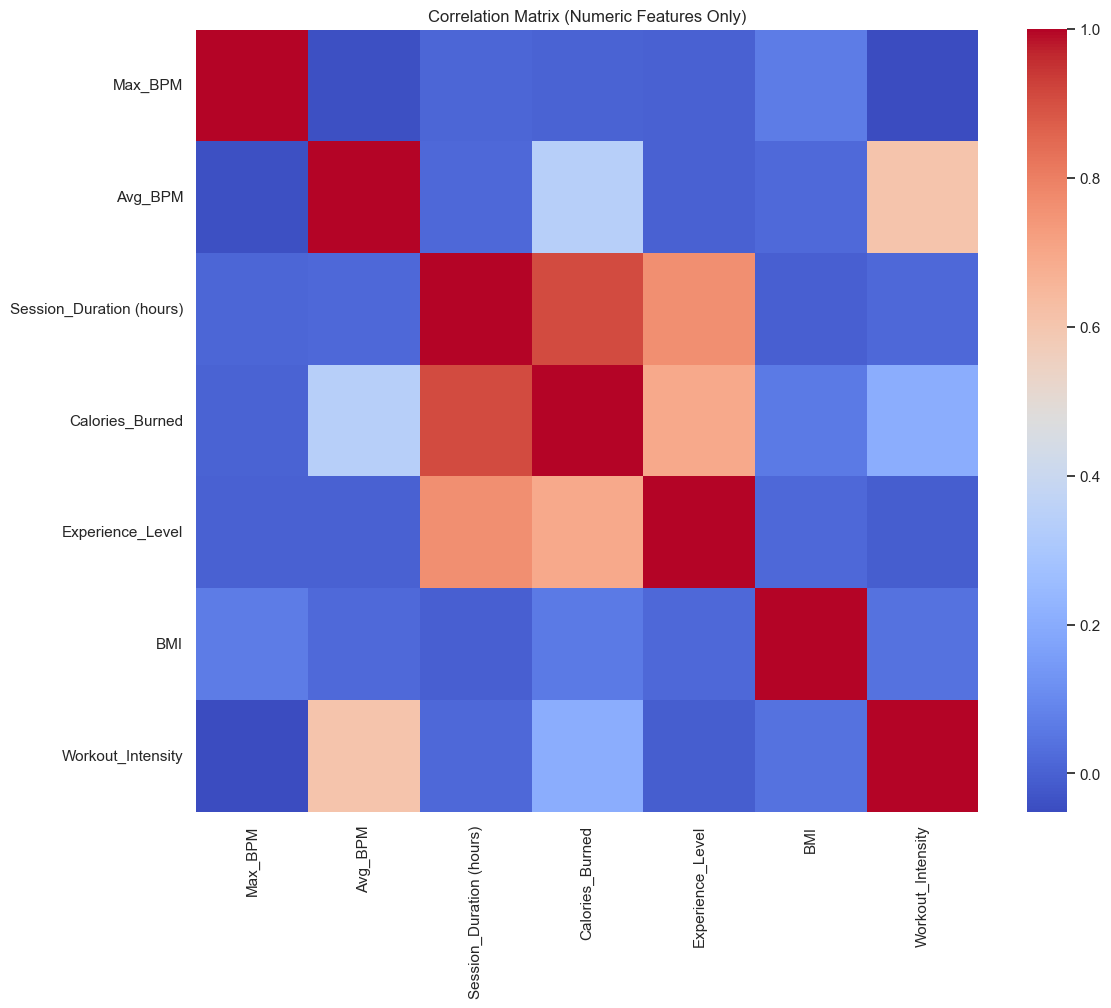

In [29]:
df_corr = df_reduced.drop(columns=['Gender', 'Workout_Type'])

plt.figure(figsize=(12, 10))
corr_matrix = df_corr.corr()
sns.heatmap(
    corr_matrix,
    cbar=True,
    annot=False,
    square=True,
    cmap="coolwarm"
)
plt.title("Correlation Matrix (Numeric Features Only)")
plt.tight_layout()
plt.show()

 7. Final modelling dataframe:
 - ensure Experience_Level is numeric
 - one-hot encode categorical variables

Now we transform Gender and Workout Type into one-hot vectors — a preprocessing step fully aligned with the report's description of categorical encoding.
This ensures the MLP receives consistent numeric inputs and keeps the modeling stage faithful to the methods documented in the Proposed Method section.

In [30]:
df_model = df_reduced.copy()

# If Experience_Level is categorical/ordinal, cast to float
df_model['Experience_Level'] = df_model['Experience_Level'].astype(float)

# One-hot encode Gender and Workout_Type
df_model = pd.get_dummies(df_model, columns=['Gender', 'Workout_Type'])

print("Final modelling columns:\n")
print(df_model.columns)
df_model.head()

Final modelling columns:

Index(['Max_BPM', 'Avg_BPM', 'Session_Duration (hours)', 'Calories_Burned',
       'Experience_Level', 'BMI', 'Workout_Intensity', 'Gender_Female',
       'Gender_Male', 'Workout_Type_Cardio', 'Workout_Type_HIIT',
       'Workout_Type_Strength', 'Workout_Type_Yoga'],
      dtype='object')


,Max_BPM,Avg_BPM,Session_Duration (hours),Calories_Burned,Experience_Level,BMI,Workout_Intensity,Gender_Female,Gender_Male,Workout_Type_Cardio,Workout_Type_HIIT,Workout_Type_Strength,Workout_Type_Yoga
0,180,157,1.69,1313.0,3.0,30.20,2.616667,False,True,False,False,False,True
1,179,151,1.30,883.0,2.0,32.00,2.287879,True,False,False,True,False,False
2,167,122,1.11,677.0,2.0,24.71,2.259259,True,False,True,False,False,False
3,190,164,0.59,532.0,1.0,18.41,2.928571,False,True,False,False,True,False
4,188,158,0.64,556.0,1.0,14.39,2.323529,False,True,False,False,True,False


8.Train/Test Split and Scaling

Standardization is done using z-scores, as detailed in the Preprocessing Module of the report.
Because neural networks are sensitive to feature scale, this step stabilizes optimization — consistent with the pipeline described in Section III.

In [ ]:
target = 'Calories_Burned'

X = df_model.drop(columns=[target])
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=seed
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


9.MLP Model Definition

This cell converts the processed data into PyTorch tensors and data loaders.
This maps directly to the “Modeling Module” described in the report, where the MLP requires batched tensor input for training.

Here we implement the exact MLP architecture described in the Algorithm Design section:
input_dim → 64 → 32 → 16 → 1.
The ReLU activations and single regression output match the report’s formal model definition.
This is where our model diverges from linear regression and can learn nonlinear metabolic relationships the report discusses.

We train the model for 100 epochs using MSE loss and Adam — again matching the hyperparameters fixed in the report for reproducibility.
As training runs, the model adjusts its weights to capture the complex feature interactions the report highlights as missing from classical formulas.

In [ ]:
# Device and tensor conversion
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_train_tensor = torch.FloatTensor(X_train).to(device)
y_train_tensor = torch.FloatTensor(y_train.values).view(-1, 1).to(device)
X_test_tensor = torch.FloatTensor(X_test).to(device)
y_test_tensor = torch.FloatTensor(y_test.values).view(-1, 1).to(device)

# Model definition
class MLP(nn.Module):
    def __init__(self, input_dim):
        super(MLP, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.layers(x)

input_dim = X_train.shape[1]
model = MLP(input_dim).to(device)

# Training setup
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
batch_size = 32
epochs = 100

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Lists for plotting
train_losses = []


# Training loop
for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * batch_X.size(0)

    # Average loss this epoch
    epoch_loss = running_loss / len(train_dataset)
    train_losses.append(epoch_loss)



    print(f"Epoch [{epoch+1}/{epochs}] - Loss: {epoch_loss:.4f} ")



TypeError: can't convert np.ndarray of type numpy.object_. The only supported types are: float64, float32, float16, complex64, complex128, int64, int32, int16, int8, uint64, uint32, uint16, uint8, and bool.

We train the model for 100 epochs using MSE loss and Adam — again matching the hyperparameters fixed in the report for reproducibility.
As training runs, the model adjusts its weights to capture the complex feature interactions the report highlights as missing from classical formulas.

9.Plot Epoch Loss

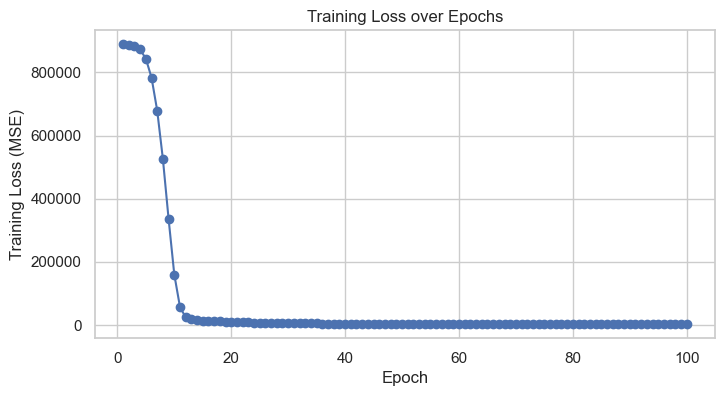

In [ ]:
# Plot training loss
plt.figure(figsize=(8, 4))
plt.plot(range(1, epochs + 1), train_losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Training Loss (MSE)')
plt.title('Training Loss over Epochs')
plt.grid(True)
plt.show()





Finally, we evaluate the model on the test set using MSE and R² — the same metrics discussed in the report’s preliminary results.
This allows us to compare the MLP directly against the linear regression baseline and empirically show whether nonlinear modeling improves calorie prediction.

10.valuation (Code Cell)


In [ ]:
# Evaluation on test set
model.eval()
with torch.no_grad():
    predictions = model(X_test_tensor).cpu().numpy().flatten()
    y_true = y_test_tensor.cpu().numpy().flatten()

mse = mean_squared_error(y_true, predictions)
r2 = r2_score(y_true, predictions)

print(f"MSE: {mse}")
print(f"R2: {r2}")





MSE: 3750.425537109375
R2: 0.9550443887710571
